In [23]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import warnings
from pathlib import Path
# read in all the data for yellow taxis
spark = SparkSession.builder.appName("Read Parquet") \
    .config("spark.driver.memory", "12g").getOrCreate()

YELLOW_DIR = Path('data/year-2026-yellow/')
# read in all the data across the times
from pathlib import Path

data_root = Path("data")
pattern = "year-*-yellow"  # matches year-2026-yellow, year-2025-yellow, etc.
dirs = sorted([d for d in data_root.glob(pattern) if d.is_dir()])

parquet_files = []
for d in dirs:
    parquet_files.extend(
        sorted([p for p in d.glob("*.parquet") if p.is_file()])
    )

yellow_raw_data = None
for p in parquet_files:
    df = spark.read.parquet(str(p))
    if yellow_raw_data is None:
        yellow_raw_data = df
    else:
        # use unionByName to be robust to column ordering / missing columns
        yellow_raw_data = yellow_raw_data.unionByName(df, allowMissingColumns=True)

print('Shape before filtering 2026 data:', (yellow_raw_data.count(), len(yellow_raw_data.columns)))
# filter out the 2026 data because its for testing
yellow_raw_data = yellow_raw_data.filter(F.year("tpep_pickup_datetime") < 2026)
yellow_raw_data = yellow_raw_data.sort('tpep_pickup_datetime')
# yellow_raw_data is the big row-wise union of all parquet files
yellow_raw_data.printSchema()

# print dataset shape
print('Shape after filtering 2026 data:', (yellow_raw_data.count(), len(yellow_raw_data.columns)))
warnings.filterwarnings("ignore", module="pyspark")

Shape before filtering 2026 data: (147201830, 20)
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



Shape after filtering 2026 data: (128202560, 20)


# Outlier analysis
## Objective: Look for outliers in the data within the columns that concern our analysis
Since `total_amount` is our only continuous column of interest, we will perform outlier analysis solely on that column. This will involve looking at the distribution of the feature and seeing where the extreme values lie, and whetehr we should remove them.

In [24]:
print('Shape before filtering null pickup and dropoff times:', (yellow_raw_data.count(), len(yellow_raw_data.columns)))
# get rid of rows with null trip durations
yellow_data = yellow_raw_data.filter((F.col("tpep_dropoff_datetime").isNotNull()) 
                                 & (F.col("tpep_pickup_datetime").isNotNull()))
print('Shape after filtering null pickup and dropoff times:', (yellow_data.count(), len(yellow_data.columns)))

Shape before filtering null pickup and dropoff times: (128202560, 20)


Shape after filtering null pickup and dropoff times: (128202560, 20)


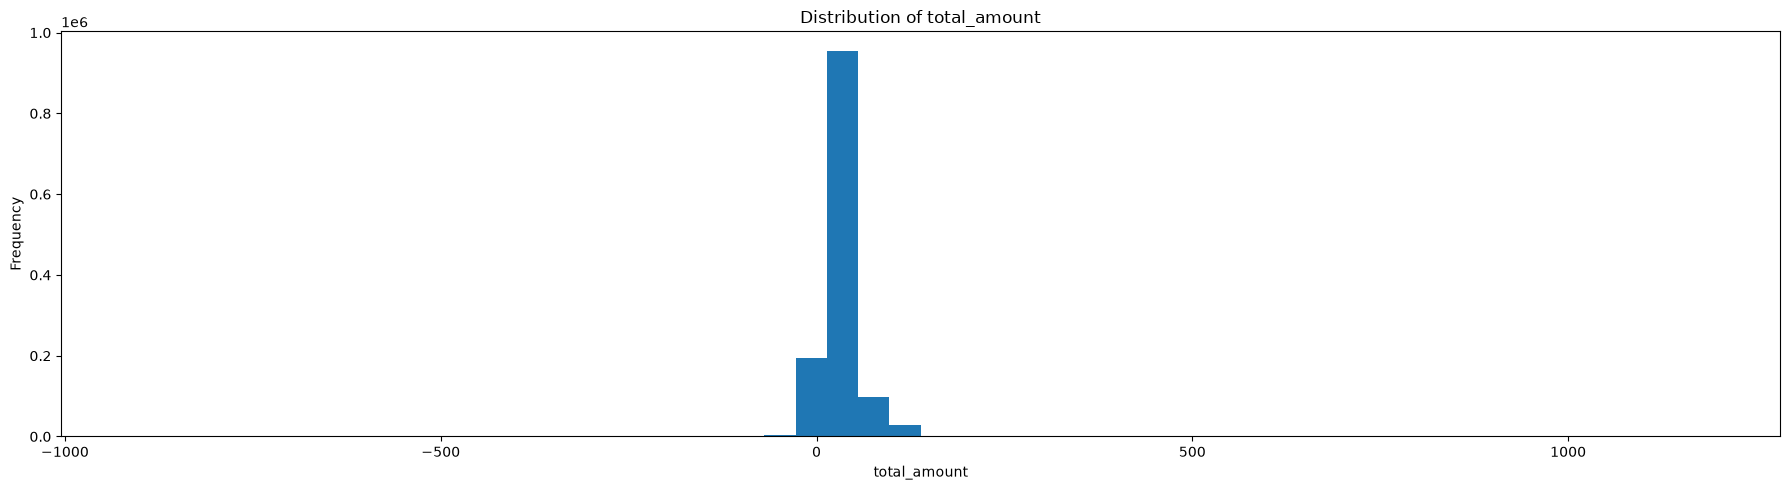

In [ ]:
import matplotlib.pyplot as plt

features = [
    "total_amount"
]

# Take a sample only for plotting
pdf = (
    yellow_data.select('total_amount')
      .sample(withReplacement=False, fraction=0.01, seed=42)
      .toPandas()
)


# plot the distribution of the target variable total_amount
fig, ax = plt.subplots(figsize=(18, 5))

ax.hist(pdf['total_amount'].dropna(), bins=50)
    
ax.set_title(f"Distribution of total_amount")
ax.set_xlabel('total_amount')
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Using quantiles to detect anomalous values
We used quantiles to decide the values to remove from our features of interest since deciding an arbitrary cutoff would risk excluding many valid records. The quantile summary below shows that at the 99th percentile, all three features exhibit extreme values which ought to be removed.

In [26]:
quantiles = [
    0.01, 0.02, 0.03, 0.04,
    0.95, 0.97, 0.98, 0.99
]

# Calculate quantiles for each feature
results = yellow_data.select('total_amount').approxQuantile(
    'total_amount',
    quantiles,
    0.01
)

# Print header
print("\n" + "=" * 75)
print("                    QUANTILE SUMMARY")
print("=" * 75)

header = f"{'Quantile':<12}"
for feature in ['total_amount']:
    header += f"{feature:>20}"

print(header)
print("-" * 75)

# Print each quantile and its corresponding values
for i, q in enumerate(quantiles):
    row = f"{q:<12.3f}"
    
    row += f"{results[i]:>20.2f}"
    
    print(row)

print("=" * 75)


                    QUANTILE SUMMARY
Quantile            total_amount
---------------------------------------------------------------------------
0.010                   -2265.45
0.020                       2.76
0.030                       4.50
0.040                       7.75
0.950                      80.29
0.970                      90.90
0.980                      98.75
0.990                  863380.37


In [27]:
# remove the outliers in total_amount based on the quantiles calculated above
# we will remove outliers based on teh 2nd and 98th quantiles, which are 2.00 and 99.00 respectively
lower_bound = results[1]
upper_bound = results[-2]
print('Before filtering outliers, shape:', (yellow_data.count(), len(yellow_data.columns)))
yellow_data = yellow_data.filter(
    (F.col("total_amount") >= lower_bound) & (F.col("total_amount") <= upper_bound)
)
print('After filtering outliers, shape:', (yellow_data.count(), len(yellow_data.columns)))

Before filtering outliers, shape: (128202560, 20)


After filtering outliers, shape: (123037675, 20)


# Takeaways
There are clear outliers within the data and anomalies that are extremely unrealistic such as negative trip durations and fares charged to passengers as well as a trip duration of 892846. We will need to decide an appropriate cutoff for the range of values we are willing to accept from each of the three features. 

<b>Deciding cutoffs</b>

Remarkably, from the percentiles output, we see that there is a steep increase in all three features going from the 98th to the 99th percentile. This is likely to suggest that there are a very rare few extreme outliers likely from some technical issues with the taxi meters that led to these results.

For simplicity's sake, we will remove the values from these columns that are greater than the 98th percentile. We will also remove values that are:

- Below the 3rd percentile `trip_distance`
- Below the 2nd percentile for `trip_duration`
- Below the 2nd percentile for `total_amount`

# Cleaning the dataset
## Objective: Remove all irrelevant rows and columns
We remove select rows where certain column values are deemed infeasible, unrealistic or not representative of the typical circumstances
surrounding yellow taxi trips. We remove certain columns if they are not useful to our analysis. 
Some rows may have unusual values in certain columns due to reasons such as recording mistakes (driver forgetting to reset system), corrupt data or system glitches. 

<b>Rows are to be removed for the following reasons</b>:
- Passenger count is 0 or null
- Trip distance is 0, null or greater than a reasonable threshold. This filters out trips that are unusual in their distance, likely due to errors in the recording system or highly exceptional circumstances.
- Trip durations are unrealistic (e.g a few seconds or too many hours)
- Drop off or pickup area is unknown, outside NYC or an area that motor vehicles cannot travel to

<b> The following columns will be retained with all others removed</b>:
- `PULocationID`: TLC ID for zone where pickup occurred. 
- `total_amount`: Total fare charged to the passengers
- `tpep_pickup_datetime`: Time that taxi picked up passengers

In [28]:
junk_locations = [264, 265, 103, 104, 110]

print('Shape before filtering junk locations: ', yellow_data.count(), ",", len(yellow_data.columns))
yellow_data = yellow_data.filter(~F.col("PULocationID").isin(junk_locations))
print('Shape after filtering junk locations: ', yellow_data.count(), ",", len(yellow_data.columns))

print('Shape before filtering null payment types and unwanted payment types: ', yellow_data.count(), ",", len(yellow_data.columns))
# get rid of rows where payment_type is null or corresponding to a voided trip as per the TLC data dictionary 
yellow_data = yellow_data.filter((F.col("payment_type").isNotNull()) 
                                 & (~F.col("payment_type").isin([6])))
print('Shape after filtering null payment types and unwanted payment types: ', yellow_data.count(), ",", len(yellow_data.columns))

print('Shape before filtering by pickup year: ', yellow_data.count(), ",", len(yellow_data.columns))
# remove rows where the year in tpep_pickup_datetime is not in range 2023-2026
yellow_data = yellow_data.withColumn(
    "pickup_year", F.year("tpep_pickup_datetime")
)
yellow_data = yellow_data.filter(
    (F.col("pickup_year") >= 2023) & (F.col("pickup_year") <= 2026)
)
print('Shape after filtering by pickup year: ', yellow_data.count(), ",", len(yellow_data.columns))
# drop unnecessary columns
yellow_data = yellow_data.select('tpep_pickup_datetime', 'PULocationID', 'total_amount')

# print shape of the cleaned data
print('Final shape (after removing unnecessary columns): ', yellow_data.count(), ",", len(yellow_data.columns))

Shape before filtering junk locations:  123037675 , 20


Shape after filtering junk locations:  122456295 , 20


Shape before filtering null payment types and unwanted payment types:  122456295 , 20


Shape after filtering null payment types and unwanted payment types:  122456295 , 20


Shape before filtering by pickup year:  122456295 , 20


Shape after filtering by pickup year:  122456166 , 21


Final shape (after removing unnecessary columns):  122456166 , 3


### Next step: Add a column for the Borough of each `PULocationID`

In [29]:
import geopandas as gpd
geo_data = gpd.read_file("data/taxi_zones/taxi_zones.shp")


print('Shape of geo_data:', geo_data.shape)
# Create Spark lookup table from geo_data
borough_lookup_pd = (
    geo_data[["LocationID", "borough"]]
    .drop_duplicates()
)
print('Shape of borough_lookup_pd:', borough_lookup_pd.shape)

borough_lookup_spark = spark.createDataFrame(borough_lookup_pd)

print('Shape before adding Borough to yellow_taxi:', (yellow_data.count(), len(yellow_data.columns)))
# Add Borough to yellow_taxi
yellow_data_with_borough = (
    yellow_data
    .join(
        borough_lookup_spark,
        yellow_data["PULocationID"] == borough_lookup_spark["LocationID"],
        how="left"
    )
    .drop("LocationID")
    .withColumnRenamed("borough", "Borough")
)
yellow_data_with_borough = yellow_data_with_borough.withColumnRenamed("tpep_pickup_datetime", "date")

print('Shape after adding Borough to yellow_taxi:', (yellow_data_with_borough.count(), len(yellow_data_with_borough.columns)))

Shape of geo_data: (263, 7)
Shape of borough_lookup_pd: (263, 2)


Shape before adding Borough to yellow_taxi: (122456166, 3)


Shape after adding Borough to yellow_taxi: (122456166, 4)


In [30]:
# save the cleaned data to a new parquet file
yellow_data_with_borough.write.parquet("cleaned_data/yellow_data.parquet", mode="overwrite")

# Cleaning the yellow taxi test dataset by applying the same preprocessing steps

In [31]:
# PREPROCESSING TEST DATA (2026 Yellow Taxi Data)
# Apply the same filtering and cleaning steps as training data

input_path_yellow_2026 = "data/year-2026-yellow"
print('Shape before reading 2026 data:', None)
yellow_data_2026 = spark.read.parquet(input_path_yellow_2026)
print('Shape after reading 2026 data:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))

# Add date column
print('Shape before adding date column:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))
yellow_data_2026 = yellow_data_2026.withColumn("date", F.to_date("tpep_pickup_datetime"))
print('Shape after adding date column:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))

# Remove junk locations
print('Shape before filtering junk locations:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))
junk_locations = [264, 265, 103, 104, 110]
yellow_data_2026 = yellow_data_2026.filter(~F.col("PULocationID").isin(junk_locations))
print('Shape after filtering junk locations:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))

# Remove invalid payment types
print('Shape before filtering invalid payment types:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))
yellow_data_2026 = yellow_data_2026.filter((F.col("payment_type").isNotNull()) 
                                 & (~F.col("payment_type").isin([6])))
print('Shape after filtering invalid payment types:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))

# Keep only relevant columns (same as training data)
print('Shape before selecting columns:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))
columns_to_retain_indices = [1, 7, 16]
yellow_data_2026 = yellow_data_2026.select('PULocationID', 'total_amount', 'date')
print('Shape after selecting columns:', (yellow_data_2026.count(), len(yellow_data_2026.columns)))

print('Final test data shape: ', yellow_data_2026.count(), ",", len(yellow_data_2026.columns))

# Save preprocessed test data
yellow_data_2026.write.mode("overwrite").parquet("cleaned_data/yellow_taxi_2026_preprocessed")

Shape before reading 2026 data: None
Shape after reading 2026 data: (18999282, 20)
Shape before adding date column: (18999282, 20)
Shape after adding date column: (18999282, 21)
Shape before filtering junk locations: (18999282, 21)
Shape after filtering junk locations: (18969563, 21)
Shape before filtering invalid payment types: (18969563, 21)
Shape after filtering invalid payment types: (18969563, 21)
Shape before selecting columns: (18969563, 21)
Shape after selecting columns: (18969563, 3)
Final test data shape:  18969563 , 3


# Cleaning the FHVHV dataset
# Remove rows if values in the features of interest are `null` or garbage (negative or wrong data type)
<b>The columns we will retain are expected to tell the equivalent information (or identical) as the yellow taxi trip data. These are</b>:
- `pickup_datetime`: Time that vehicle picked up passengers.
- `PULocationID`: TLC ID for taxi zone where pickup occurred.

Additionally, we will create a new column called `trip_volume` which will be aggregated to a daily frequency
and will represent the market share of high volume for-hire vehicles. 


In [ ]:
pattern = "year-*-fhvhv"  # matches year-2026-yellow, year-2025-yellow, etc.
dirs = sorted([d for d in data_root.glob(pattern) if d.is_dir()])

parquet_files = []
for d in dirs:
    parquet_files.extend(
        sorted([p for p in d.glob("*.parquet") if p.is_file()])
    )

# read all parquet files and combine them into a single DataFrame
fhvhv_data_raw = None
for p in parquet_files:
    df = spark.read.parquet(str(p))
    if fhvhv_data_raw is None:
        fhvhv_data_raw = df
    else:
        # use unionByName to be robust to column ordering / missing columns
        fhvhv_data_raw = fhvhv_data_raw.unionByName(df, allowMissingColumns=True)

fhvhv_data = fhvhv_data_raw
# fhvhv_data is the big row-wise union of all parquet files
print(f"Combined {len(parquet_files)} files. {fhvhv_data.count()} rows")
fhvhv_data.printSchema()

# print the dataset shape
print('Shape: ', fhvhv_data.count(), ',', len(fhvhv_data.columns))

Combined 41 files. 821546266 rows
root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nul

In [33]:
# data cleaning
# remove rows where PULocationID is in the list of invalid IDs
print('Shape before filtering junk locations:', (fhvhv_data.count(), len(fhvhv_data.columns)))
fhvhv_data = fhvhv_data.filter(~F.col("PULocationID").isin(junk_locations))
print('Shape after filtering junk locations:', (fhvhv_data.count(), len(fhvhv_data.columns)))

print('Shape before selecting columns:', (fhvhv_data.count(), len(fhvhv_data.columns)))

fhvhv_data = fhvhv_data.select('pickup_datetime', 'PULocationID')
print('Shape after selecting columns:', (fhvhv_data.count(), len(fhvhv_data.columns)))

print('Shape before renaming date column:', (fhvhv_data.count(), len(fhvhv_data.columns)))
fhvhv_data = fhvhv_data.withColumnRenamed("pickup_datetime", "date")
print('Shape after renaming date column:', (fhvhv_data.count(), len(fhvhv_data.columns)))

Shape before filtering junk locations: (821546266, 25)


Shape after filtering junk locations: (821508685, 25)


Shape before selecting columns: (821508685, 25)


Shape after selecting columns: (821508685, 2)


Shape before renaming date column: (821508685, 2)


Shape after renaming date column: (821508685, 2)


In [34]:
# save the cleaned data to a new parquet file
fhvhv_data.write.mode("overwrite").parquet("cleaned_data/fhvhv_data.parquet")

# Cleaning the test FHVHV data

In [35]:
# PREPROCESSING TEST DATA (2026 FHVHV Data)
# Apply the same filtering and cleaning steps as training data

input_path_fhvhv_2026 = "data/year-2026-fhvhv"
print('Shape before reading 2026 FHVHV data:', None)
fhvhv_data_2026 = spark.read.parquet(input_path_fhvhv_2026)
print('Shape after reading 2026 FHVHV data:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))

# Add date column
print('Shape before adding date column:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))
fhvhv_data_2026 = fhvhv_data_2026.withColumn("date", F.to_date("pickup_datetime"))
print('Shape after adding date column:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))

# Keep only relevant columns for trip volume calculation
print('Shape before selecting columns:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))
fhvhv_data_2026 = fhvhv_data_2026.select(['PULocationID', 'date'])
print('Shape after selecting columns:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))

print('Final test FHVHV data shape: ', fhvhv_data_2026.count(), ",", len(fhvhv_data_2026.columns))

# Save preprocessed test FHVHV data
fhvhv_data_2026.write.mode("overwrite").parquet("cleaned_data/fhvhv_2026_preprocessed.parquet")

Shape before reading 2026 FHVHV data: None
Shape after reading 2026 FHVHV data: (105996114, 25)
Shape before adding date column: (105996114, 25)
Shape after adding date column: (105996114, 26)
Shape before selecting columns: (105996114, 26)
Shape after selecting columns: (105996114, 2)
Final test FHVHV data shape:  105996114 , 2


In [ ]:
# retrieve the MapPLUTO data for residential information
residential_data = spark.read.csv('data/MAPPLUTO.csv', header=True, inferSchema=True)
residential_data.show(2)

+--------+-------+-----+---+---+------+------+----------+-------+-------+--------+----------+--------------------+----------+---------+-------------+--------+----------------+---------+---------+---------+---------+--------+--------+-------+-------+-------+---------+---------+---------+-------+---------+---------+--------------------+-------+--------+-------+-------+----------+----------+----------+---------+----------+---------+----------+--------+---------+--------+----------+--------+--------+---------+---------+----+--------+----------+-------+--------+----------+---------+---------+---------+----------+----------+--------+-------------------+--------+--------+-------+--------+--------+----------+-------+---------+------+------+-------+------+-------+------+---------+----------+----------+----------+-------+-----------+------------+---------+----------+-----------+-----+----------+-------+-----------+----------+----------+----------+----------+--------------------+---------+-------

In [37]:
# remove prisons and also vacant areas (code starts with 'V')
print('Shape before filtering out prisons and vacant areas:', (residential_data.count(), len(residential_data.columns)))
residential_data = residential_data.filter(F.col('BldgClass') != 'Y3')
residential_data = residential_data.filter(~F.col('BldgClass').startswith('V'))
print('Shape after filtering out prisons and vacant areas:', (residential_data.count(), len(residential_data.columns)))

Shape before filtering out prisons and vacant areas: (856687, 103)
Shape after filtering out prisons and vacant areas: (831931, 103)


In [38]:
# Select only the critical columns for analysis
critical_features = [
    'OBJECTID',
    'Borough',
    'UnitsRes',
    'NumBldgs',
    'BldgClass',
    'ResArea',
    'LotArea',
    'NumFloors',
    'BBL'
]
 
# Filter to only buildings with residential units
print('Shape before selecting critical features:', (residential_data.count(), len(residential_data.columns)))
residential_filtered = (residential_data
    .select(critical_features)
    .filter(F.col('UnitsRes') > 0)
)
print('Shape after selecting critical features and filtering UnitsRes > 0:', (residential_filtered.count(), len(residential_filtered.columns)))
print(f"\nTotal residential tax lots: {residential_filtered.count()}")
print(f"Total residential units: {residential_filtered.agg({'UnitsRes': 'sum'}).collect()[0][0]}")


Shape before selecting critical features: (831931, 103)
Shape after selecting critical features and filtering UnitsRes > 0: (767063, 9)

Total residential tax lots: 767063
Total residential units: 3729426


In [39]:
# Filter geopandas geodataframe to match PySpark filtered data

import geopandas as gpd

# Load the full shapefile
residential_geo_raw_data = gpd.read_file('data/MAPPLUTO/MAPPLUTO.shp')

# Get the list of OBJECTIDs from the filtered PySpark dataframe
# First, convert PySpark dataframe to list of OBJECTIDs
objectid_list = residential_filtered.select('OBJECTID').rdd.flatMap(lambda x: x).collect()

print(f"Number of residential buildings with units: {len(objectid_list)}")

# Filter geopandas dataframe to only include OBJECTIDs in the filtered list
features = ['OBJECTID', 'geometry']
residential_geo_data = residential_geo_raw_data[
    residential_geo_raw_data['OBJECTID'].isin(objectid_list)
][features]

print(f"Geodataframe shape: {residential_geo_data.shape}")
print(f"Sample data:")
print(residential_geo_data.head())

# Verify: check that all OBJECTIDs match
print(f"\nVerification - OBJECTIDs in geo_data: {len(residential_geo_data)}")
print(f"OBJECTIDs in filtered data: {len(objectid_list)}")
print(f"Match: {len(residential_geo_data) == len(objectid_list)}")

Number of residential buildings with units: 767063
Geodataframe shape: (767063, 2)
Sample data:
    OBJECTID                                           geometry
5          6  POLYGON ((-8238822.37 4968678.859, -8238850.69...
6          7  POLYGON ((-8238850.691 4968669.142, -8238862.3...
7          8  POLYGON ((-8239065.098 4968596.127, -8239076.9...
9         10  POLYGON ((-8238982.993 4968801.027, -8238982.8...
11        12  POLYGON ((-8239402.588 4969155.989, -8239332.1...

Verification - OBJECTIDs in geo_data: 767063
OBJECTIDs in filtered data: 767063
Match: True


In [40]:
# Spatial join residential buildings to LocationIDs and aggregate by zone

# Step 1: Convert PySpark dataframe to pandas/geopandas for spatial operations
residential_pandas = residential_filtered.toPandas()

# Step 2: Add geometry to residential data by merging with residential_geo_data
residential_with_geo = residential_geo_data.merge(
    residential_pandas,
    on='OBJECTID',
    how='inner'
)

# Convert to GeoDataFrame if not already
residential_with_geo = gpd.GeoDataFrame(residential_with_geo, geometry='geometry')
residential_with_geo.head()

,OBJECTID,geometry,Borough,UnitsRes,NumBldgs,BldgClass,ResArea,LotArea,NumFloors,BBL
0,6,"POLYGON ((-8238822.37 4968678.859, -8238850.69...",MN,42,1.0,RM,32843.0,7780.0,6.0,1000077501
1,7,"POLYGON ((-8238850.691 4968669.142, -8238862.3...",MN,1,1.0,RM,9807.0,3095.0,4.5,1000077502
2,8,"POLYGON ((-8239065.098 4968596.127, -8239076.9...",MN,97,1.0,RM,126420.0,9053.0,19.0,1000087501
3,10,"POLYGON ((-8238982.993 4968801.027, -8238982.8...",MN,3,1.0,RM,5461.0,2242.0,5.0,1000117501
4,12,"POLYGON ((-8239402.588 4969155.989, -8239332.1...",MN,293,1.0,D8,331746.0,13465.0,31.0,1000150022


In [41]:
# Reproject to match if they differ
if residential_with_geo.crs != geo_data.crs:
    print(f"  -> Reprojecting residential_with_geo to match geo_data CRS...")
    residential_with_geo = residential_with_geo.to_crs(geo_data.crs)
    print(f"  -> Done!")
 
# Step 3: Spatial join - assign each building to its LocationID zone
buildings_by_zone = gpd.sjoin(
    residential_with_geo,
    geo_data,
    how='left',
    predicate='within'
)
aggregation_dict = {
    'UnitsRes': 'sum',             # Total residential units
    'NumBldgs': 'sum',             # Total number of buildings
    'ResArea': 'sum',              # Total residential floor area
    'LotArea': 'sum',              # Total lot area
    'NumFloors': 'mean',           # Average number of floors
}
 
demand_proxy_by_zone = buildings_by_zone.groupby('LocationID').agg(aggregation_dict)
 
# Rename columns to be more descriptive
demand_proxy_by_zone = demand_proxy_by_zone.rename(columns={
    'UnitsRes': 'TotalResidentialUnits',
    'NumBldgs': 'TotalNumBldgs',
    'ResArea': 'TotalResidentialArea',
    'LotArea': 'TotalLotArea',
    'YearBuilt': 'AvgYearBuilt',
    'NumFloors': 'AvgNumFloors'
})
 
# Add count of building lots (number of rows per zone)
demand_proxy_by_zone['NumBuildingLots'] = buildings_by_zone.groupby('LocationID').size()

  -> Reprojecting residential_with_geo to match geo_data CRS...
  -> Done!


In [43]:
print("Shape:", demand_proxy_by_zone.shape)
demand_proxy_by_zone.head()

Shape: (239, 6)


,TotalResidentialUnits,TotalNumBldgs,TotalResidentialArea,TotalLotArea,AvgNumFloors,NumBuildingLots
LocationID,,,,,,
3.0,9674,6268.0,9671960.0,16660256.0,1.950959,5191
4.0,13758,564.0,11224175.0,3847828.0,5.615801,465
5.0,9413,8056.0,12647308.0,23359782.0,2.142045,7391
6.0,5482,3915.0,6511248.0,14518605.0,1.969606,3171
7.0,39273,8182.0,31054624.0,20521217.0,2.679809,6713


In [44]:
# save to CSV
demand_proxy_by_zone.to_csv('cleaned_data/residential_data.csv', index=True)